In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import os
import warnings

warnings.filterwarnings("ignore")

## <SARIMAX 모델>

In [176]:
from statsmodels.api import datasets

data = datasets.macrodata.load_pandas().data
data

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,2008.0,3.0,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
199,2008.0,4.0,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
200,2009.0,1.0,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
201,2009.0,2.0,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19


In [177]:
data = data[["year", "quarter", "realgdp", "realcons", "realinv", "realgovt", "realdpi", "cpi"]].copy()
data

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.980
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.150
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.350
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.370
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.540
...,...,...,...,...,...,...,...,...
198,2008.0,3.0,13324.600,9267.7,1990.693,991.551,9838.3,216.889
199,2008.0,4.0,13141.920,9195.3,1857.661,1007.273,9920.4,212.174
200,2009.0,1.0,12925.410,9209.2,1558.494,996.287,9926.4,212.671
201,2009.0,2.0,12901.504,9189.0,1456.678,1023.528,10077.5,214.469


In [178]:
### 원본데이터
data

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.980
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.150
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.350
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.370
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.540
...,...,...,...,...,...,...,...,...
198,2008.0,3.0,13324.600,9267.7,1990.693,991.551,9838.3,216.889
199,2008.0,4.0,13141.920,9195.3,1857.661,1007.273,9920.4,212.174
200,2009.0,1.0,12925.410,9209.2,1558.494,996.287,9926.4,212.671
201,2009.0,2.0,12901.504,9189.0,1456.678,1023.528,10077.5,214.469


In [179]:
### 결측치 확인
data.isnull().sum()

year        0
quarter     0
realgdp     0
realcons    0
realinv     0
realgovt    0
realdpi     0
cpi         0
dtype: int64

In [180]:
### 시계열 전처리

data["year"] = pd.to_datetime(data["year"], format="%Y")
data = data.set_index("year").copy()
data

,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi
year,,,,,,,
1959-01-01,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.980
1959-01-01,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.150
1959-01-01,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.350
1959-01-01,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.370
1960-01-01,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.540
...,...,...,...,...,...,...,...
2008-01-01,3.0,13324.600,9267.7,1990.693,991.551,9838.3,216.889
2008-01-01,4.0,13141.920,9195.3,1857.661,1007.273,9920.4,212.174
2009-01-01,1.0,12925.410,9209.2,1558.494,996.287,9926.4,212.671


In [181]:
### 데이터 분할 (train 170개, test 33개)
train = data.iloc[:170, :]
test = data.iloc[170:, :]

In [183]:
### 종속변수, 외생변수 구분하기

train_target = train[["realgdp"]]                ### 훈련데이터 종속변수
test_target = test[["realgdp"]]                  ### 테스트데이터 종속변수
train_exog = train[["realcons", "realinv", "realgovt", "realdpi", "cpi"]]   ### 훈련데이터 외생변수
test_exog = test[["realcons", "realinv", "realgovt", "realdpi", "cpi"]]     ### 테스트데이터 외생변수

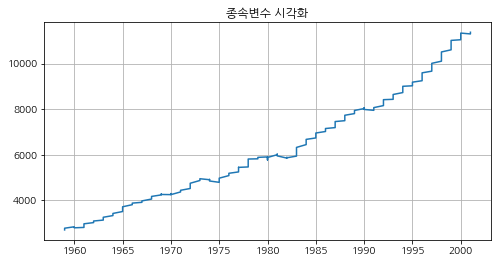

In [119]:
### 종속변수 시각화

plt.figure(figsize=(8,4))

plt.title("종속변수 시각화")
plt.plot(train_target)

plt.grid()
plt.show()

In [120]:
### 종속변수 정상성 확인
from statsmodels.tsa.stattools import adfuller

# H0 : 시계열에 단위근이 존재한다.(= 비정상 시계열)
# H1 : 시계열에 단위근이 존재하지 않는다.(=정상 시계열)

result = adfuller(train_target["realgdp"])

s = result[0]
p = result[1]

print(f"검정통계량 : {s}")
print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량 : 2.341670696691554
검정통계량의 p-value : 0.9989801598345119
귀무가설 채택


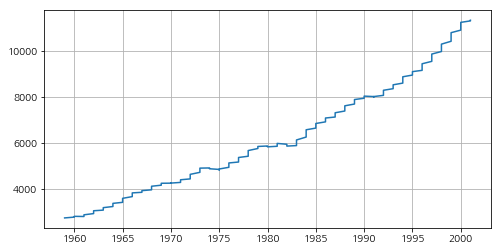

In [121]:
## 시차에 따라 평균이 일정한지 확인

rolling_mean = train_target["realgdp"].rolling(window=4).mean()

plt.figure(figsize=(8,4))

plt.plot(rolling_mean)

plt.grid()
plt.show()

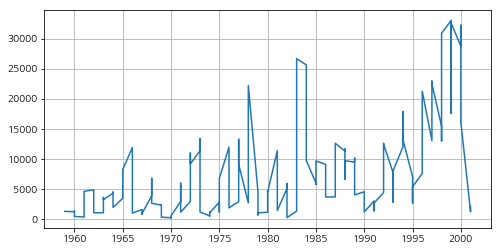

In [122]:
## 시차에 따라 분산이 일정한지 확인

rolling_var = train_target["realgdp"].rolling(window=4).var()

plt.figure(figsize=(8,4))

plt.plot(rolling_var)

plt.grid()
plt.show()

In [123]:
# ### 종속변수에 0보다 작거나 같은 값 있는지 확인

# cond = (train_target["realgdp"] <= 0)
# train_target.loc[cond, :]

In [124]:
# ### 종속변수 박스콕스 변환
# from sklearn.preprocessing import PowerTransformer

# ptb = PowerTransformer(method="box-cox")
# train_target[["realgdp_boxcox"]] = ptb.fit_transform(train_target[["realgdp"]])
# train_target

In [125]:
# ### 종속변수 정상성 재확인
# from statsmodels.tsa.stattools import adfuller

# # H0 : 시계열에 단위근이 존재한다.(= 비정상 시계열)
# # H1 : 시계열에 단위근이 존재하지 않는다.(=정상 시계열)

# result = adfuller(train_target["realgdp_boxcox"])

# s = result[0]
# p = result[1]

# print(f"검정통계량 : {s}")
# print(f"검정통계량의 p-value : {p}")
# print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

In [126]:
### 종속변수에 차분 진행

train_target["realgdp_diff"] = train_target["realgdp"].diff()
train_target

,realgdp,realgdp_diff
year,,
1959-01-01,2710.349,NaN
1959-01-01,2778.801,68.452
1959-01-01,2775.488,-3.313
1959-01-01,2785.204,9.716
1960-01-01,2847.699,62.495
...,...,...
2000-01-01,11258.454,215.410
2000-01-01,11267.867,9.413
2000-01-01,11334.544,66.677


In [127]:
### 종속변수 정상성 재확인
from statsmodels.tsa.stattools import adfuller

# H0 : 시계열에 단위근이 존재한다.(= 비정상 시계열)
# H1 : 시계열에 단위근이 존재하지 않는다.(=정상 시계열)

result = adfuller(train_target["realgdp_diff"].dropna())

s = result[0]
p = result[1]

print(f"검정통계량 : {s}")
print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량 : -5.726593528129708
검정통계량의 p-value : 6.748984598396614e-07
귀무가설 기각


In [129]:
### ARIMAX 모델 적합
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools

# 탐색할 차수 범위
p = q = range(0, 5)    # p, q 차수
d = [1]                # 차분 차수 (이미 차분한 경우 0)
P = Q = range(0, 5)    # P, Q 차수
D = [0]                # 계절 차분 차수
m = [0]                # 계절성 주기 (없으면 0, 월간이면 12 등)

results = []

for order in itertools.product(p, d, q):
    for seasonal_order in itertools.product(P, D, Q, m):
        try:
            model = SARIMAX(
                            train_target["realgdp"],      # 종속변수(행의 개수 일치해야함)
                            exog=train_exog,              # 외생변수(행의 개수 일치해야함)  
                            order=order,
                            seasonal_order=seasonal_order
                            ).fit()
            
            results.append({
                           "order": order,                    
                            "seasonal_order": seasonal_order,  
                            "AIC": model.aic
                           })
            
        except Exception:
            continue

# DataFrame으로 정리
df_results = pd.DataFrame(results)
df_results

,order,seasonal_order,AIC
0,"(0, 1, 0)","(0, 0, 0, 0)",1459.600728
1,"(0, 1, 1)","(0, 0, 0, 0)",1460.489946
2,"(0, 1, 2)","(0, 0, 0, 0)",1461.057234
3,"(0, 1, 3)","(0, 0, 0, 0)",1462.800488
4,"(0, 1, 4)","(0, 0, 0, 0)",1459.756806
5,"(1, 1, 0)","(0, 0, 0, 0)",1460.222065
6,"(1, 1, 1)","(0, 0, 0, 0)",1455.514378
7,"(1, 1, 2)","(0, 0, 0, 0)",1456.433423
8,"(1, 1, 3)","(0, 0, 0, 0)",1456.266809
9,"(1, 1, 4)","(0, 0, 0, 0)",1454.444370


In [130]:
df_results.sort_values(by="AIC", ascending=True)

,order,seasonal_order,AIC
13,"(2, 1, 3)","(0, 0, 0, 0)",1449.089720
24,"(4, 1, 4)","(0, 0, 0, 0)",1450.064168
18,"(3, 1, 3)","(0, 0, 0, 0)",1450.799830
12,"(2, 1, 2)","(0, 0, 0, 0)",1453.373184
14,"(2, 1, 4)","(0, 0, 0, 0)",1453.714841
9,"(1, 1, 4)","(0, 0, 0, 0)",1454.444370
6,"(1, 1, 1)","(0, 0, 0, 0)",1455.514378
8,"(1, 1, 3)","(0, 0, 0, 0)",1456.266809
21,"(4, 1, 1)","(0, 0, 0, 0)",1456.383874
7,"(1, 1, 2)","(0, 0, 0, 0)",1456.433423


In [150]:
### 최적의 ARIMAX 모델 적합

model = SARIMAX(
                train_target["realgdp"],      # 종속변수(행의 개수 일치해야함)
                exog=train_exog,              # 외생변수(행의 개수 일치해야함)  
                order=(2, 1, 3),
                seasonal_order=(0, 0, 0, 0)
                ).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                realgdp   No. Observations:                  170
Model:               SARIMAX(2, 1, 3)   Log Likelihood                -713.545
Date:                Thu, 28 Aug 2025   AIC                           1449.090
Time:                        23:55:26   BIC                           1483.519
Sample:                             0   HQIC                          1463.062
                                - 170                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
realcons       0.9617      0.050     19.313      0.000       0.864       1.059
realinv        1.0753      0.033     32.846      0.000       1.011       1.139
realgovt       0.7596      0.124      6.112      0.000       0.516       1.003
realdpi        0.0112      0.039      0.286      0.775      -0.066       0.088
cpi            3.5829      1.898      1.888      0.059      -0.136       7.302
ar.L1          1.8135      0.070     25.892      0.000       1.676       1.951
ar.L2         -0.9001      0.069    -13.002      0.000      -1.036      -0.764
ma.L1         -1.8260      0.114    -16.080      0.000      -2.049      -1.603
ma.L2          0.9519      0.181      5.255      0.000       0.597       1.307
ma.L3          0.0137      0.091      0.151      0.880      -0.164       0.192
sigma2       270.3887     27.529      9.822      0.000     216.433     324.344
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                25.83
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               4.38   Skew:                             0.41
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.73
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [151]:
## 잔차 분석

In [152]:
## 잔차의 독립성(융박스 검정)
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = model.resid

result = acorr_ljungbox(residuals)
result

,lb_stat,lb_pvalue
1,0.025056,0.874227
2,0.122906,0.940397
3,0.181882,0.980460
4,1.386853,0.846477
5,1.452424,0.918494
6,1.493282,0.959940
7,1.630540,0.977443
8,1.650009,0.989928
9,1.652532,0.995849
10,1.667084,0.998314


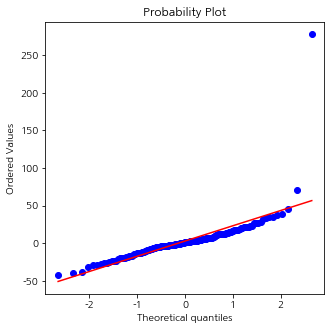

In [153]:
## 잔차의 정규성 (Q-Q plot)
from scipy.stats import probplot

residuals = model.resid

plt.figure(figsize=(5,5))

probplot(residuals, dist="norm", plot=plt)

plt.show()

In [154]:
### 잔차의 등분산성 (Arch 검정)
from statsmodels.stats.diagnostic import het_arch

# H0 : 잔차가 등분산성을 만족한다.
# H1 : 잔차가 등분산성을 만족하지 않는다.

residuals = model.resid

s, p , fstat, f_pvalue = het_arch(residuals)

print(f"검정통계량의 p-value : {p}")
print("귀무가설 채택" if p > 0.05 else "귀무가설 기각")

검정통계량의 p-value : 0.5597908005959085
귀무가설 채택


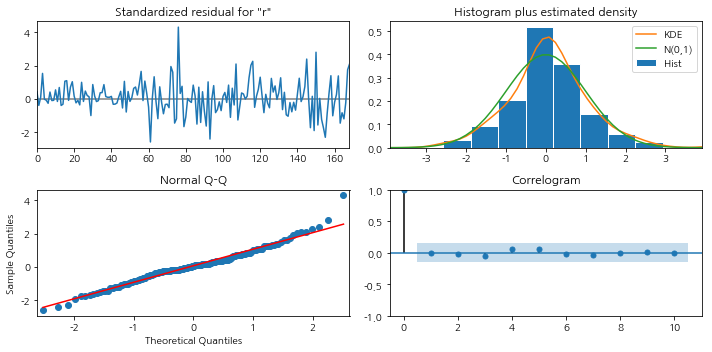

In [155]:
model.plot_diagnostics(figsize=(10,5))

plt.tight_layout()
plt.show()

In [165]:
### 예측하기

pred = model.forecast(steps=len(test_target),   # test 종속변수 개수
                      exog=test_exog            # test 외생변수
                      )
pred

170    11372.986527
171    11390.383933
172    11511.060463
173    11601.096462
174    11682.502770
175    11735.116403
176    11787.314102
177    11911.014715
178    12102.861608
179    12234.024097
180    12333.130613
181    12476.383573
182    12587.788289
183    12719.022832
184    12831.640603
185    12868.418156
186    12980.147501
187    13070.389229
188    13221.902005
189    13265.211301
190    13281.620451
191    13311.106277
192    13358.061641
193    13435.978040
194    13509.129297
195    13510.431517
196    13475.671678
197    13452.318253
198    13350.438225
199    13135.246809
200    12821.000419
201    12720.611059
202    12837.981395
Name: predicted_mean, dtype: float64

In [172]:
### 인덱스 값 맞추기
pred.index = test_target["realgdp"].index
pred

year
2001-01-01    11372.986527
2001-01-01    11390.383933
2002-01-01    11511.060463
2002-01-01    11601.096462
2002-01-01    11682.502770
2002-01-01    11735.116403
2003-01-01    11787.314102
2003-01-01    11911.014715
2003-01-01    12102.861608
2003-01-01    12234.024097
2004-01-01    12333.130613
2004-01-01    12476.383573
2004-01-01    12587.788289
2004-01-01    12719.022832
2005-01-01    12831.640603
2005-01-01    12868.418156
2005-01-01    12980.147501
2005-01-01    13070.389229
2006-01-01    13221.902005
2006-01-01    13265.211301
2006-01-01    13281.620451
2006-01-01    13311.106277
2007-01-01    13358.061641
2007-01-01    13435.978040
2007-01-01    13509.129297
2007-01-01    13510.431517
2008-01-01    13475.671678
2008-01-01    13452.318253
2008-01-01    13350.438225
2008-01-01    13135.246809
2009-01-01    12821.000419
2009-01-01    12720.611059
2009-01-01    12837.981395
Name: predicted_mean, dtype: float64

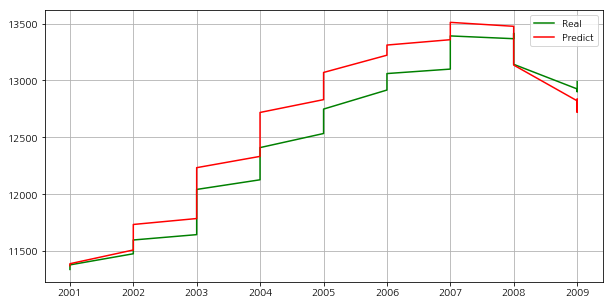

In [173]:
### 예측 시각화

plt.figure(figsize=(10,5))

plt.plot(test_target["realgdp"], color="green", label="Real")
plt.plot(pred, color="red", label="Predict")

plt.legend()
plt.grid()
plt.show()

In [175]:
### 성능 평가
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test_target["realgdp"], pred)

print(f"ARIMAX 모델 MAE : {mae}")

ARIMAX 모델 MAE : 178.177875252343
